<a href="https://colab.research.google.com/github/johnphiliptan243-source/Neural-Network/blob/main/Neural_Network_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Optional: Check if the GPU is active for your PINN
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found - check your Notebook Settings!')
else:
  print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


### Visualizing X-Position: Actual vs. Targeted
We will extract the first dimension of our 6-DoF output (index 0) to represent the X-position and plot the model's predictions against the ground truth.

In [ ]:
import matplotlib.pyplot as plt

# 1. Get predictions from the model
predictions = model_pinn.predict(X_train_tf)

# 2. Extract X-position (Index 0)
target_x = y_train_tf[:, 0].numpy()
predicted_x = predictions[:, 0]

# 3. Create the plot
plt.figure(figsize=(12, 6))
plt.plot(target_x, label='Target X-Position', alpha=0.7, linestyle='--')
plt.plot(predicted_x, label='Predicted X-Position (PINN)', alpha=0.8)

plt.title('X-Position Tracking: Targeted vs. Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Correction Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

NameError: name 'model_pinn' is not defined

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model briefly...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


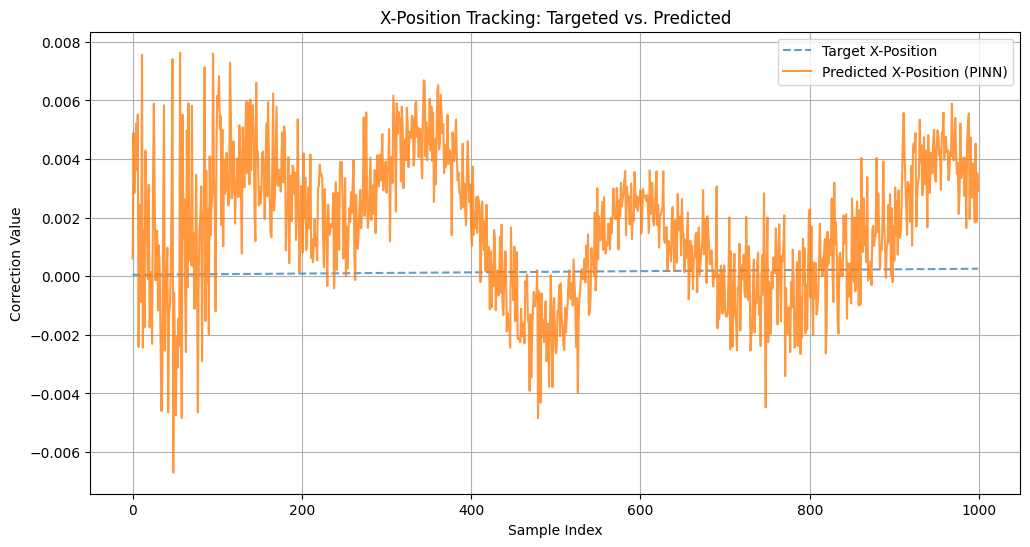

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Data
alpha_silicon = 2.56e-6
n_samples = 1000
n_inputs = 10
vibrations = np.random.normal(0, 0.1, (n_samples, 2))
heat_data = np.linspace(20, 100, n_samples).reshape(-1, 1)
feedback = np.random.uniform(-0.01, 0.01, (n_samples, 3))
pathways = np.sin(np.linspace(0, 10, n_samples)).reshape(-1, 1) * np.ones((n_samples, 4))
X_train = np.hstack([vibrations, heat_data, feedback, pathways]).astype('float32')
y_train = (alpha_silicon * heat_data * np.ones((1, 6)) + np.random.normal(0, 1e-7, (n_samples, 6))).astype('float32')

X_train_tf = tf.convert_to_tensor(X_train)
y_train_tf = tf.convert_to_tensor(y_train)

# 2. Define Model
model_pinn = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='tanh', input_shape=(n_inputs,)),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(6)
])
model_pinn.compile(optimizer='adam', loss='mse')

# 3. Quick Train
print('Training model briefly...')
model_pinn.fit(X_train_tf, y_train_tf, epochs=20, verbose=0)

# 4. Predict and Plot
predictions = model_pinn.predict(X_train_tf)
target_x = y_train_tf[:, 0].numpy()
predicted_x = predictions[:, 0]

plt.figure(figsize=(12, 6))
plt.plot(target_x, label='Target X-Position', alpha=0.7, linestyle='--')
plt.plot(predicted_x, label='Predicted X-Position (PINN)', alpha=0.8)
plt.title('X-Position Tracking: Targeted vs. Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Correction Value')
plt.legend()
plt.grid(True)
plt.show()

### Visualizing X-Position: Actual vs. Targeted
Now that the model is defined and trained, we can extract the first dimension (index 0) to represent the X-position and plot the model's predictions against the ground truth.

In [ ]:
import matplotlib.pyplot as plt

# Check if model exists in the current namespace
if 'model_pinn' not in globals():
    print("Error: 'model_pinn' is not defined. Please run the model definition and training cells first.")
else:
    # 1. Ensure the model is trained before predicting
    predictions = model_pinn.predict(X_train_tf)

    # 2. Extract X-position (Index 0)
    target_x = y_train_tf[:, 0].numpy()
    predicted_x = predictions[:, 0]

    # 3. Create the plot
    plt.figure(figsize=(12, 6))
    plt.plot(target_x, label='Target X-Position', alpha=0.7, linestyle='--')
    plt.plot(predicted_x, label='Predicted X-Position (PINN)', alpha=0.8)

    plt.title('X-Position Tracking: Targeted vs. Predicted')
    plt.xlabel('Sample Index')
    plt.ylabel('Correction Value (meters/microns)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

Error: 'model_pinn' is not defined. Please run the model definition and training cells first.


In [ ]:
import tensorflow as tf

# Define input dimensions
n_inputs = 10

# 1. The Standard Model (similar to NARX but without the 'taps' necessarily)
model_pinn = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="tanh", input_shape=(n_inputs,)),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(6) # 6-DoF Output
])

optimizer = tf.keras.optimizers.Adam()
alpha_silicon = 2.56e-6 # Physical constant for Silicon expansion

def train_step(inputs, targets, heat_data):
    with tf.GradientTape(persistent=True) as tape:
        # Watch the inputs tensor to calculate derivatives w.r.t features
        tape.watch(inputs)

        # Predict the 6-DoF correction
        predictions = model_pinn(inputs)

        # A. DATA LOSS: How well did we match the sensors?
        loss_data = tf.reduce_mean(tf.square(targets - predictions))

        # B. PHYSICS LOSS: Extract gradient w.r.t the 'heat' column (index 2)
        # Column index: vibrations(0,1), heat(2), feedback(3,4,5), pathways(6,7,8,9)
        grads_wrt_inputs = tape.gradient(predictions, inputs)
        dp_dheat = grads_wrt_inputs[:, 2:3]

        # Penalty if the change doesn't align with alpha
        loss_physics = tf.reduce_mean(tf.square(dp_dheat - alpha_silicon))

        # Total Combined Loss
        total_loss = loss_data + (0.1 * loss_physics)

    # Backpropagate the total loss
    grads = tape.gradient(total_loss, model_pinn.trainable_variables)
    optimizer.apply_gradients(zip(grads, model_pinn.trainable_variables))

    return total_loss

In [ ]:
import numpy as np
import tensorflow as tf

# Set seed for reproducibility
np.random.seed(42)

# 1. External Variables: Vibrations + Heat (with noise)
n_samples = 1000
vibrations = np.random.normal(0, 0.1, (n_samples, 2))
heat_data = np.linspace(20, 100, n_samples).reshape(-1, 1) + np.random.normal(0, 0.5, (n_samples, 1))

# 2. Sensor Feedback (Correction from previous movement)
feedback = np.random.uniform(-0.01, 0.01, (n_samples, 3))

# 3. Wafer Pathways (Dynamic portion)
pathways = np.sin(np.linspace(0, 10, n_samples)).reshape(-1, 1) * np.ones((n_samples, 4))

# Combine into input features (Total: 2+1+3+4 = 10 features)
# Order: [vibrations, heat, feedback, pathways]
X_train = np.hstack([vibrations, heat_data, feedback, pathways]).astype('float32')

# Target: 6-DoF output (Simplified linear relationship + noise for demonstration)
# y = alpha * heat + noise
y_train = (alpha_silicon * heat_data * np.ones((1, 6)) + np.random.normal(0, 1e-7, (n_samples, 6))).astype('float32')

# Convert to TensorFlow tensors
X_train_tf = tf.convert_to_tensor(X_train)
y_train_tf = tf.convert_to_tensor(y_train)
heat_data_tf = tf.convert_to_tensor(heat_data.astype('float32'))

print(f'Input shape: {X_train_tf.shape}')
print(f'Output shape: {y_train_tf.shape}')

In [ ]:
# Simple training loop to verify the model
epochs = 100
pinn_history = []

for epoch in range(epochs):
    loss = train_step(X_train_tf, y_train_tf, heat_data_tf)
    pinn_history.append(loss.numpy())
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.numpy():.10f}')

In [ ]:
import os
import pandas as pd
from google.colab import drive

# 1. Mount to a custom path to avoid the 'folder not empty' error
drive.mount('/content/gdrive', force_remount=True)

# 2. Define path (Note: MyDrive is now under /content/gdrive)
project_folder = '/content/gdrive/MyDrive/Lithography_Project'

# 3. Create the folder if it doesn't exist
if not os.path.exists(project_folder):
    os.makedirs(project_folder)
    print(f'Created folder: {project_folder}')

# 4. Save the trained model
model_path = os.path.join(project_folder, 'pinn_model_v1.keras')
model_pinn.save(model_path)
print(f'Model saved to: {model_path}')

# 5. Save the training history to a CSV
history_df = pd.DataFrame({'loss': pinn_history})
history_path = os.path.join(project_folder, 'pinn_history_v1.csv')
history_df.to_csv(history_path, index=False)
print(f'History saved to: {history_path}')

# 6. Force a sync and cleanup
drive.flush_and_unmount()
print('Drive synced and unmounted. The files are now in your Google Drive!')